В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc, f1_score, accuracy_score, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import joblib

np.set_printoptions(legacy='1.25')

Area under ROC score on Train dataset: 0.90%



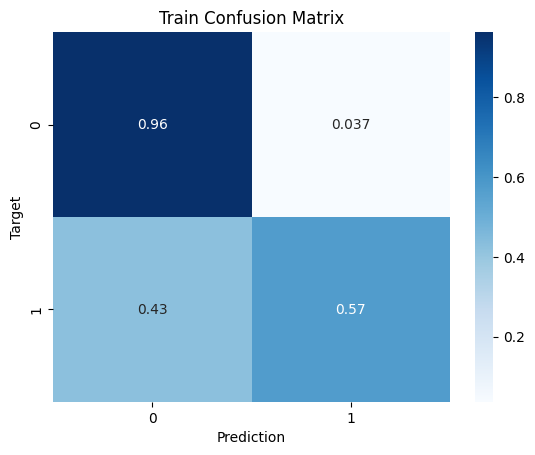


Area under ROC score on Validation dataset: 0.88%



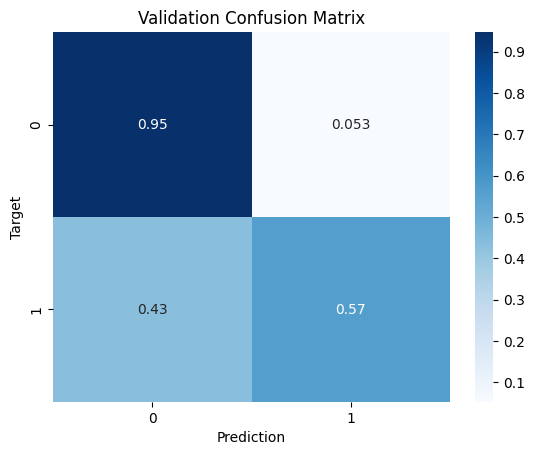

In [3]:
raw_df = pd.read_csv("drive/MyDrive/Colab Notebooks/data/train.csv", index_col=0)

train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df["Exited"])

# Create inputs and targets
input_cols = list(train_df.columns)[1:-1]
target_col = 'Exited'

train_inputs, train_targets = train_df[input_cols], train_df[target_col]
val_inputs, val_targets = val_df[input_cols], val_df[target_col]

# Identify numeric and categorical columns
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Create preprocessing pipelines for both numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Combine transformers for different types of columns into one preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Create a pipeline that includes preprocessing and the model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Train the model
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    y_pred_proba = model_pipeline.predict_proba(inputs)[:, 1]

    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    print(f'Area under ROC score on {name} dataset: {roc_auc:.2f}%')

    print('')
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show();
    print('')
    return preds

# Evaluate on validation and train set
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Save the trained model
joblib.dump(model_pipeline, 'bank_customer_churn_prediction.joblib');

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

In [4]:
def train_poly_model(degree: int):
  numeric_transformer_poly = Pipeline(steps=[
      ('poly', PolynomialFeatures(degree=degree)),
      ('scaler', MinMaxScaler())
  ])

  preprocessor_poly = ColumnTransformer(
      transformers=[
          ('num', numeric_transformer_poly, numeric_cols),
          ('cat', categorical_transformer, categorical_cols)
      ])

  model_pipeline_poly = Pipeline(steps=[
      ('preprocessor', preprocessor_poly),
      ('classifier', LogisticRegression(solver='liblinear'))
  ])

  model_pipeline_poly.fit(train_inputs, train_targets)

  return model_pipeline_poly

Area under ROC score on Train dataset: 0.93%



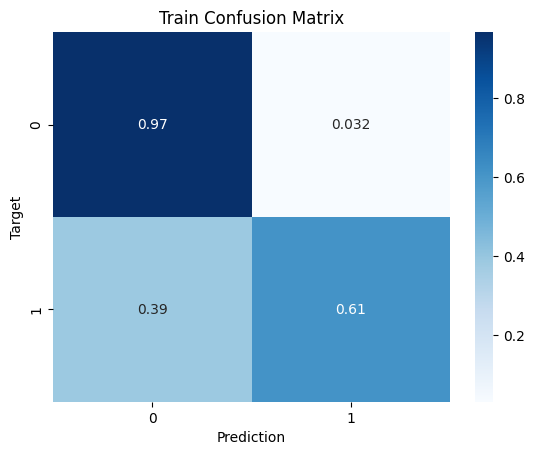


Area under ROC score on Validation dataset: 0.91%



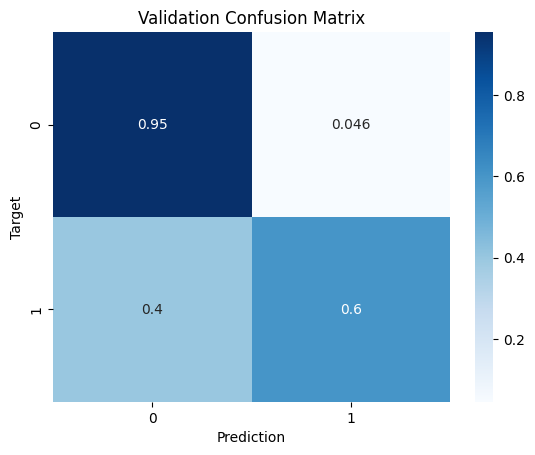

In [5]:
model_pipeline_poly_2 = train_poly_model(2)

train_preds = predict_and_plot(model_pipeline_poly_2, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_poly_2, val_inputs, val_targets, 'Validation')

Різниця між тренувальним та валідаційним AUROC дуже мала (0.02).

Обидва значення високі i покращились в порівнянні з попередньоою моделю (понад 0.9).

Це свідчить про хорошу узагальнюючу здатність моделі — ані overfitting, ані underfitting не спостерігається.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Train dataset: 0.94%



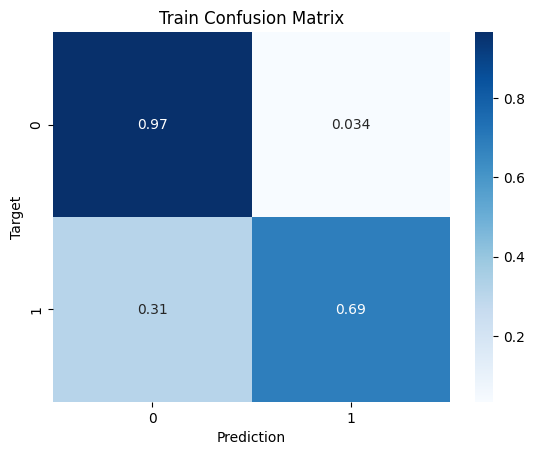


Area under ROC score on Validation dataset: 0.93%



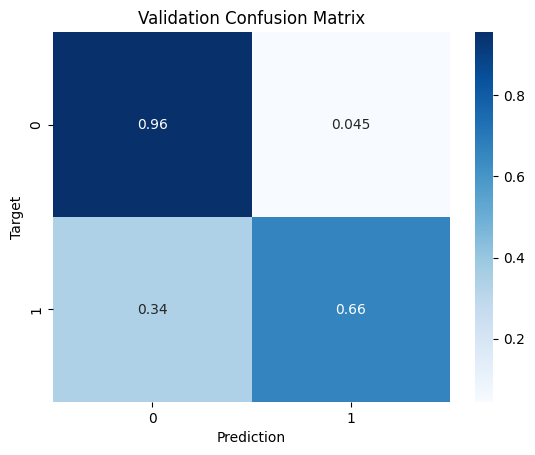

In [6]:
model_pipeline_poly_2 = train_poly_model(4)

train_preds = predict_and_plot(model_pipeline_poly_2, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_poly_2, val_inputs, val_targets, 'Validation')

Точність моделі ще покращилась. 0.93%-0.94% дуже хороший результат

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [7]:
regression_df = pd.read_csv("drive/MyDrive/Colab Notebooks/data/regression_data.csv")
display(regression_df.head(3))

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482


In [8]:
regression_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_1  129 non-null    float64
 1   feature_2  129 non-null    float64
 2   feature_3  129 non-null    float64
 3   feature_4  129 non-null    float64
 4   feature_5  129 non-null    float64
 5   target     129 non-null    float64
dtypes: float64(6)
memory usage: 6.2 KB


In [9]:
inputs = regression_df.drop(columns=['target'])
targets = regression_df["target"]

X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.2, random_state=42)

numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Create preprocessing pipelines for both numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=5)),
    ('scaler', MinMaxScaler())
])

# Combine transformers for different types of columns into one preprocessor
preprocessor = ColumnTransformer(
    transformers=[
    ('num', numeric_transformer, numeric_cols),
])

# Create a pipeline that includes preprocessing and the model
model_linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LinearRegression())
])

# Train the model
model_linear_pipeline.fit(X_train, y_train)

# Predict and evaluate
y_train_pred = model_linear_pipeline.predict(X_train)
y_test_pred = model_linear_pipeline.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f'RMSE train: {rmse_train:.4f}%')
print(f'RMSE test: {rmse_test:.4f}%')

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print('')
print(f'R² score train: {train_r2:.2f}%')
print(f'R² score test: {test_r2:.2f}%')

RMSE train: 0.0000%
RMSE test: 12.3633%

R² score train: 1.00%
R² score test: 0.93%


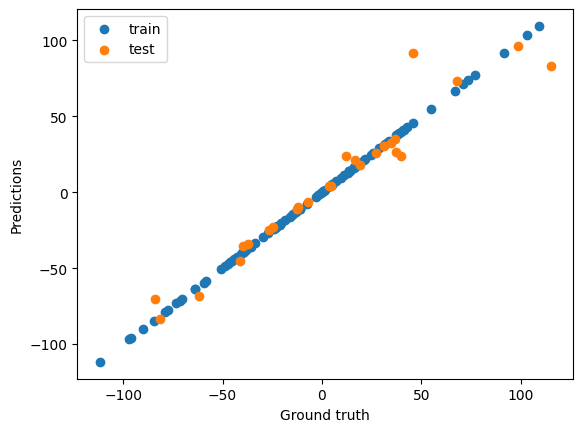

In [10]:
plt.scatter(y_train, y_train_pred, label='train')
plt.scatter(y_test, y_test_pred, label='test')
plt.xlabel('Ground truth')
plt.ylabel('Predictions')
plt.legend();

RMSE train = 0.0000% → модель ідеально передбачає тренувальні дані.  
RMSE test = 12.3633% → модель суттєво гірше працює на нових даних, порівняно з тренувальними.  
Модель надто добре запам’ятала тренувальні дані, тому вона перенавчена.

R² train = 1.00 → теж свідчить про ідеальну відповідність тренувальним даним.  
R² test = 0.93 → на перший погляд гарна генералізація, але RMSE показує інше

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [11]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet

models = [
    LinearRegression(),
    Ridge(),
    Ridge(alpha=2),
    Lasso(),
    ElasticNet(),
    ElasticNet(alpha=0.5)
]

In [12]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred)).round(6)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred)).round(6)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    return {
      'Train RMSE': train_rmse,
      'Test RMSE': test_rmse,
      'Train R2': train_r2,
      'Test R2': test_r2
    }

In [13]:
numeric_transformer_poly_20 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=20)),
    ('scaler', MinMaxScaler())
])

preprocessor_poly_20 = ColumnTransformer(
    transformers=[
    ('num', numeric_transformer_poly_20, numeric_cols),
])

In [14]:
results = {}

for model in models:
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_poly_20),
        ('classifier', model)
    ])
    model_pipeline.fit(X_train, y_train)
    eval_results  = evaluate_model(model_pipeline, X_train, y_train, X_test, y_test)
    results[model] = eval_results

pd.DataFrame(results).T

,Train RMSE,Test RMSE,Train R2,Test R2
LinearRegression(),0.000000,15.674311,1.000000,0.894695
Ridge(),8.597750,76.562708,0.962049,-1.512509
Ridge(alpha=2),12.406284,94.079153,0.920981,-2.793673
Lasso(),5.098171,5.671931,0.986656,0.986211
ElasticNet(),34.179765,116.029707,0.400227,-4.770474
ElasticNet(alpha=0.5),29.380210,154.530517,0.556842,-9.235324


In [17]:
np.std(y_train), np.std(y_test)

(44.13422004765026, 48.30181674637871)

Найкращий результат показала модель Lasso()  
У неї спостерігаємо найточніші метрики і значення метрик для тренувальних і валідаційних даних  дуже схожі  
Також середня помилка прогнозу моделі значно менша за розкид значень самої цільової змінної (standard deviation)